### liner regression

In [177]:
# house price dataset
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [178]:
housing = fetch_california_housing()

In [179]:
type(housing)

sklearn.utils._bunch.Bunch

In [180]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [181]:
dataset =pd.DataFrame(housing.data, columns=housing.feature_names).head()

In [182]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [183]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing()
dataset = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)


dataset["price"] = housing.target


print(dataset.shape)
print(dataset.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


## dividing the dataset into independent and dependent fetures

In [184]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [185]:
X.head()
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: price, dtype: float64

### linear regression

In [186]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg = LinearRegression()

mse = cross_val_score(
    lin_reg,
    X,
    y,
    scoring='neg_mean_squared_error',
    cv=5
)
mean_mse=np.mean(mse)

print(mean_mse)

-0.5582901717686554


### RIDGE regression

In [187]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    "alpha": [0.1, 1, 10, 100]
}

ridge_regressor = GridSearchCV(
    ridge,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_regressor.fit(X, y)

print("Best Alpha:", ridge_regressor.best_params_)
print("Best Score:", ridge_regressor.best_score_)

Best Alpha: {'alpha': 100}
Best Score: -0.5579724434119415


### lasso-l1 regularization

In [188]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV


lasso = Lasso()


params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}


lasso_regressor = GridSearchCV(
    lasso,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)


lasso_regressor.fit(X, y)


print("Best Alpha:", lasso_regressor.best_params_)
print("Best Score:", lasso_regressor.best_score_)

Best Alpha: {'alpha': 0.001}
Best Score: -0.5582759293868985


In [189]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score


X, y = load_diabetes(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)


lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Ridge R²:", r2_score(y_test, ridge_pred))
print("Lasso R²:", r2_score(y_test, lasso_pred))

print("Ridge Coefficients:")
print(ridge.coef_)

print("Lasso Coefficients:")
print(lasso.coef_)

Ridge R²: 0.41915292635986545
Lasso R²: 0.4718547867276227
Ridge Coefficients:
[  45.36737726  -76.66608563  291.33883165  198.99581745   -0.53030959
  -28.57704987 -144.51190505  119.26006559  230.22160832  112.14983004]
Lasso Coefficients:
[   0.         -152.66477923  552.69777529  303.36515791  -81.36500664
   -0.         -229.25577639    0.          447.91952518   29.64261704]


## comparing with all regression models

In [190]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": ridge_regressor.best_estimator_,
    "Lasso Regression": lasso_regressor.best_estimator_
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MSE": mse,
        "R2 Score": r2
    }

for model, scores in results.items():
    print("\n", model)
    print("MSE:", scores["MSE"])
    print("R2 Score:", scores["R2 Score"])


 Linear Regression
MSE: 2900.1936284934804
R2 Score: 0.4526027629719197

 Ridge Regression
MSE: 5233.663686578425
R2 Score: 0.012171803489062438

 Lasso Regression
MSE: 2896.4097872031957
R2 Score: 0.4533169443449512


## feature scaling

In [191]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Rdige regression scaling

In [192]:
ridge = Ridge()

ridge_regressor = GridSearchCV(
    ridge,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_regressor.fit(X_train_scaled, y_train)

ridge_pred = ridge_regressor.predict(X_test_scaled)

print("Ridge MSE:",
      mean_squared_error(y_test, ridge_pred))

print("Ridge R2:",
      r2_score(y_test, ridge_pred))

Ridge MSE: 2875.778718421843
Ridge R2: 0.45721095677808476


## lasso

In [193]:
lasso = Lasso()

lasso_regressor = GridSearchCV(
    lasso,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)

lasso_regressor.fit(X_train_scaled, y_train)

lasso_pred = lasso_regressor.predict(X_test_scaled)

print("Lasso MSE:",
      mean_squared_error(y_test, lasso_pred))

print("Lasso R2:",
      r2_score(y_test, lasso_pred))

Lasso MSE: 2824.568094049959
Lasso R2: 0.46687670944102466


## visualization

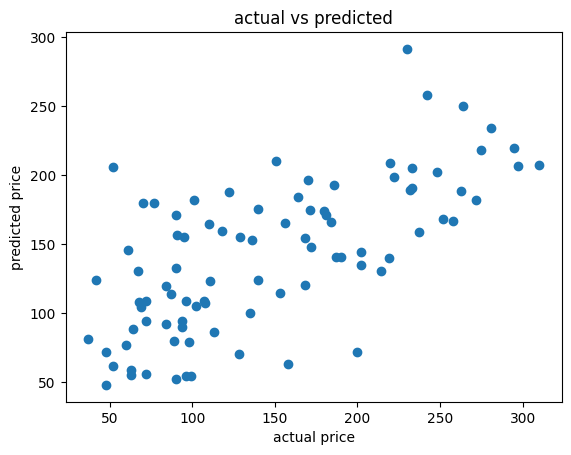

In [194]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted")
plt.show()

## best fit or best model

In [195]:
import pickle


best_lasso = lasso_regressor.best_estimator_

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(best_lasso, file)

print("Model saved successfully")

Model saved successfully


## logistic regression

In [196]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
df=load_breast_cancer()
X=pd.DataFrame(df['data'],columns=df['feature_names'])
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [197]:
y=pd.DataFrame(df['target'],columns=["target"])
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [198]:
y['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [199]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.33,random_state=42


)

params=[{'c':[1,5,10]},{'max_iter':[100,150]}]


modell1=LogisticRegression(C=100,max_iter=100)

model=GridSearchCV(modell1,param_grid=params,scoring='f1',cv=5)

In [200]:
GridSearchCV(cv=5,estimator=LogisticRegression(C=100),param_grid=[{'c':[1,5,10]},{'max_iter':[100,150]}],scoring='f1')

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression(C=100)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'c': [1, 5, ...]}, {'max_iter': [100, 150]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

#### 1. Bayes' Theorem

The foundation of Naive Bayes is:

P(A∣B)=
P(B)
P(B∣A)P(A)
	​


For machine learning:

P(Class∣Features)=
P(Features)
P(Features∣Class)P(Class)
	​


Where:

P(Class∣Features) = Posterior probability
P(Features∣Class) = Likelihood
P(Class) = Prior probability
P(Features) = Evidence

Since P(Features) is the same for every class, for classification we can compare:

P(Class∣Features)∝P(Features∣Class)P(Class)

## pseudo code
naviesbayes(training_data)
For each class C:
    calculate prior:
    p(c)

    For each feature X:
       calculate:
        p(X|C)


 For each new sample:
    For each class c:
        score =p(c) 

        For each feature x:
         score=score *p(X|C)
                   


In [201]:


## create sample dataset


import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# --------------------------------------------------
# 1. Create sample dataset
# --------------------------------------------------

data = {
    "message": [
        "Congratulations! You won a free lottery ticket",
        "Win a free iPhone now, click the link",
        "Claim your cash prize immediately",
        "You have won a free vacation",
        "Get free money by registering today",
        "URGENT! You won a lottery prize",
        "Free recharge available, claim now",
        "Congratulations, you are selected for a cash reward",

        "Hey, are you coming to college today?",
        "Can you send me the assignment?",
        "Don't forget our meeting tomorrow",
        "What time will you reach home?",
        "Please call me when you are free",
        "I will send the notes tonight",
        "Let's meet after class",
        "Your exam is scheduled for Monday"
    ],

    "label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",

        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham"
    ]
}

df = pd.DataFrame(data)


# --------------------------------------------------
# 2. Display dataset
# --------------------------------------------------

print("Dataset:")
print(df)

print("\nClass distribution:")
print(df["label"].value_counts())


# --------------------------------------------------
# 3. Separate input and output
# --------------------------------------------------

X = df["message"]
y = df["label"]


# --------------------------------------------------
# 4. Split dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 5. Convert text into numerical features
# --------------------------------------------------

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# --------------------------------------------------
# 6. Create Naive Bayes model
# --------------------------------------------------

model = MultinomialNB()


# --------------------------------------------------
# 7. Train model
# --------------------------------------------------

model.fit(X_train_tfidf, y_train)


# --------------------------------------------------
# 8. Make predictions
# --------------------------------------------------

y_pred = model.predict(X_test_tfidf)


# --------------------------------------------------
# 9. Evaluate model
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# --------------------------------------------------
# 10. Test new messages
# --------------------------------------------------

new_messages = [
    "Congratulations you won a free prize",
    "Can you send me your class notes?",
    "Claim your cash reward now",
    "Are you coming to college tomorrow?"
]


# Convert new messages into TF-IDF
new_messages_tfidf = vectorizer.transform(new_messages)


# Predict
predictions = model.predict(new_messages_tfidf)


# Display predictions
print("\nNew Message Predictions:")

for message, prediction in zip(new_messages, predictions):
    print(f"\nMessage: {message}")
    print(f"Prediction: {prediction}")




Dataset:
                                              message label
0      Congratulations! You won a free lottery ticket  spam
1               Win a free iPhone now, click the link  spam
2                   Claim your cash prize immediately  spam
3                        You have won a free vacation  spam
4                 Get free money by registering today  spam
5                     URGENT! You won a lottery prize  spam
6                  Free recharge available, claim now  spam
7   Congratulations, you are selected for a cash r...  spam
8               Hey, are you coming to college today?   ham
9                     Can you send me the assignment?   ham
10                  Don't forget our meeting tomorrow   ham
11                     What time will you reach home?   ham
12                   Please call me when you are free   ham
13                      I will send the notes tonight   ham
14                             Let's meet after class   ham
15                  Your exam i

### decision tree

Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



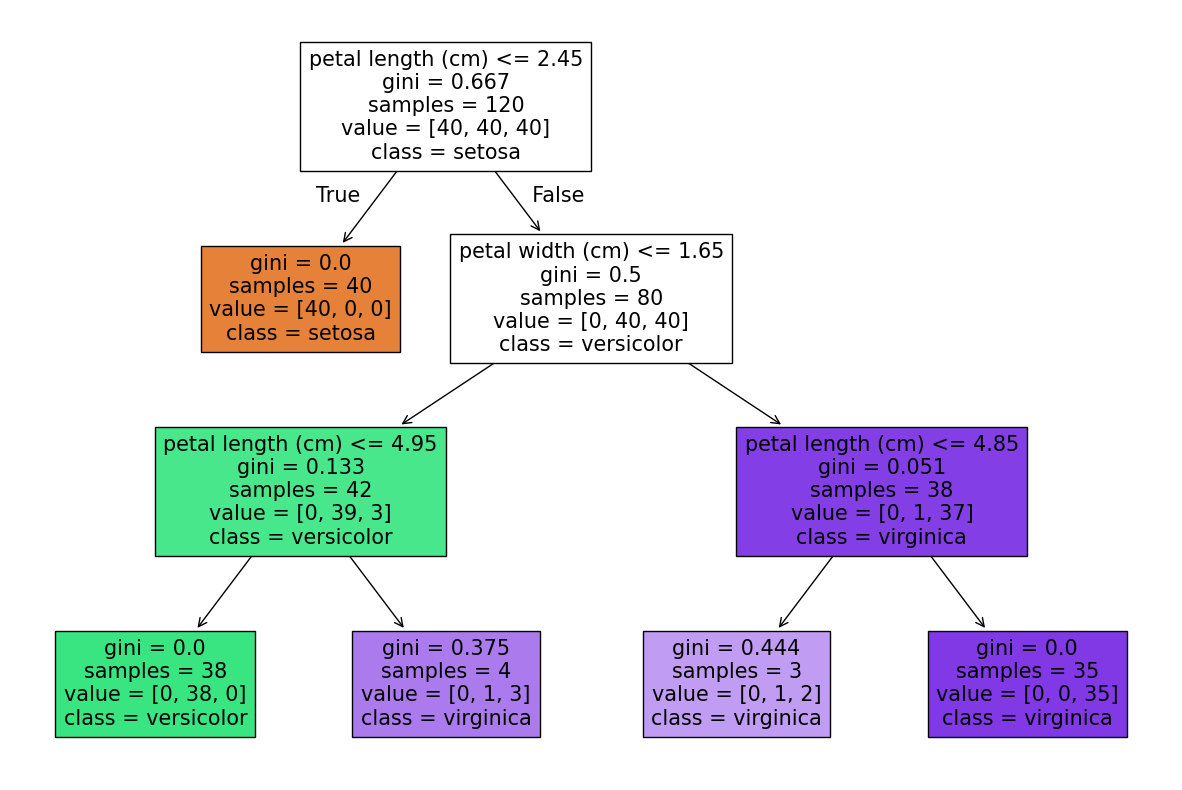

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# 1. Load dataset
iris = load_iris()

X = iris.data
y = iris.target



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()